#  Exploratory Data Analysis and Intro

## Goal
1. Investigate top-paying roles and skills in the data science industry.
2. Use Pythin to explore a real-live dataset on job postings.
3. for job-seekers: use these insights to help find the best job oppoetunities.

## Final Deliverables:
- Create Jupyter Notebooks(Showcasing core skills in Python)
- Create a summary page (via README.md) capturing your findings.
- Share this project via GitHub &LinkedIn 

## Questions to Answer
1. What are the most demanded skills for the top 3 most popular data roles?
2. How are in-demand skills trending for Data Scientist?
3. How well do jobs and skills pay for Data Scientist?
4. what is the most optimal skill to learn for Data Scientist?(High Demand AND High Paying)

# Exploratory Data Analysis for all Data roles


# Roles to explor

In [89]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import ast
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [90]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_title_short        785741 non-null  object 
 1   job_title              785740 non-null  object 
 2   job_location           784696 non-null  object 
 3   job_via                785733 non-null  object 
 4   job_schedule_type      773074 non-null  object 
 5   job_work_from_home     785741 non-null  bool   
 6   search_location        785741 non-null  object 
 7   job_posted_date        785741 non-null  object 
 8   job_no_degree_mention  785741 non-null  bool   
 9   job_health_insurance   785741 non-null  bool   
 10  job_country            785692 non-null  object 
 11  salary_rate            33067 non-null   object 
 12  salary_year_avg        22003 non-null   float64
 13  salary_hour_avg        10662 non-null   float64
 14  company_name           785723 non-nu

## Cleanup the Data

In [92]:
#Convert object to datetime
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [93]:
#Convert object to list
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x) 

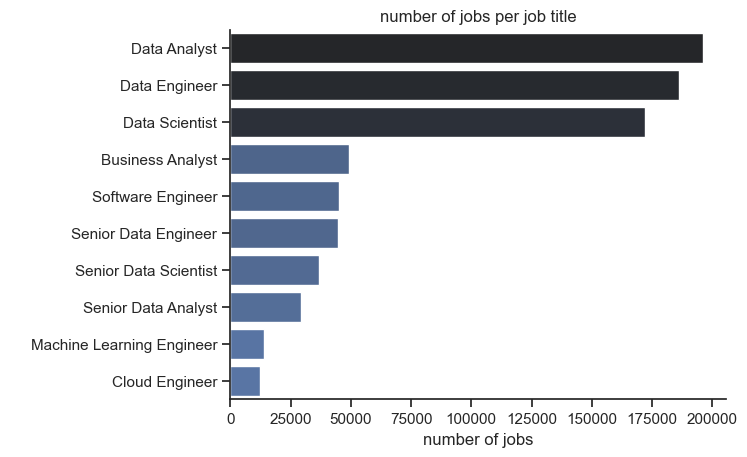

In [94]:
df_plot = df['job_title_short'].value_counts().to_frame()

sns.set_theme(style= 'ticks')
sns.barplot(data = df_plot, x = 'count', y = 'job_title_short',hue='count',palette ='dark:b_r',legend = False)
sns.despine()
plt.title('number of jobs per job title')
plt.ylabel(' ')
plt.xlabel('number of jobs')
plt.show()

# Country to explore

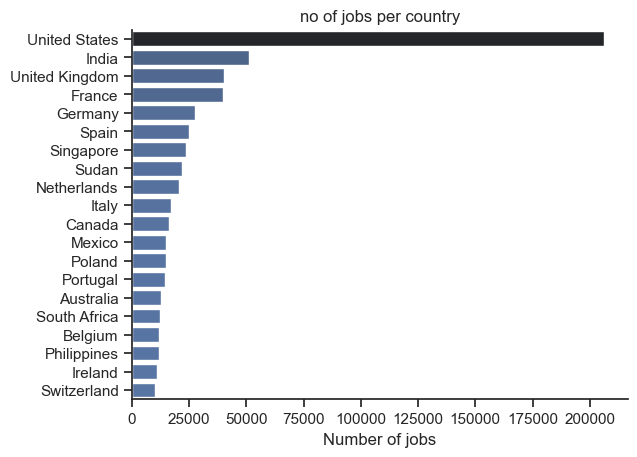

In [95]:
df_plot = df['job_country'].value_counts().to_frame().head(20)

sns.set_theme(style = 'ticks')
sns.barplot(data = df_plot, x = 'count', y='job_country',hue = 'count', palette = 'dark:b_r',legend = False)
sns.despine()
plt.title('no of jobs per country')
plt.ylabel('')
plt.xlabel('Number of jobs')
plt.show()

# Company to Explore

Text(0.5, 0, 'Number of jobs')

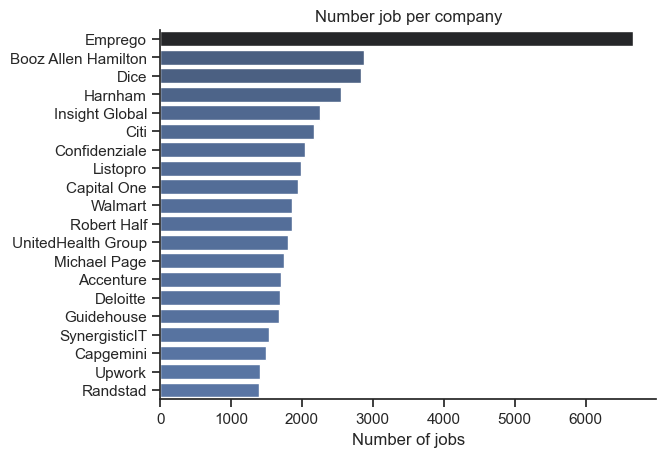

In [96]:
df_plot = df['company_name'].value_counts().head(20).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data= df_plot, x = 'count', y= 'company_name',hue = 'count', palette = 'dark:b_r',legend = False)
sns.despine()
plt.title('Number job per company')
plt.ylabel('')
plt.xlabel('Number of jobs')

# Job oppertunities

In [97]:
df.sample(5)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
152266,Data Engineer,Data Engineer,"Palma, Spain",via LinkedIn,Full-time,False,Spain,2023-06-22 08:17:59,True,False,Spain,None,NaN,NaN,Grupo Viajes El Corte Inglés,"[mongodb, mongodb, java, python, scala, sql, n...","{'cloud': ['bigquery'], 'databases': ['mongodb..."
501409,Senior Data Engineer,Senior Data Engineer,"Hyderabad, Telangana, India",via Jooble,Full-time,False,India,2023-03-22 11:28:06,True,False,India,None,NaN,NaN,Flutter International plc,"[sql, t-sql, nosql, python, kafka, flutter, ss...","{'analyst_tools': ['ssis'], 'libraries': ['kaf..."
278739,Data Analyst,Data Analyst,"Santiago, Chile","via Trabajo.org - Vacantes De Empleo, Trabajo",Full-time,False,Chile,2023-08-30 07:32:50,True,False,Chile,None,NaN,NaN,SumUp,"[sql, python, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
496544,Cloud Engineer,DevOps Engineer with AWS Job,"Novi Sad, Serbia",via LinkedIn,Full-time,False,Serbia,2023-07-24 11:30:49,False,False,Serbia,None,NaN,NaN,NTT DATA Romania,"[go, aws, terraform, kubernetes, jenkins, dock...","{'async': ['jira'], 'cloud': ['aws'], 'other':..."
150738,Business Analyst,ET7R - Data Governance Business Analyst (m/f/d),"Donauworth, Germany",via LinkedIn,Full-time,False,Germany,2023-09-04 08:18:10,False,False,Germany,None,NaN,NaN,Airbus,"[nosql, python]","{'programming': ['nosql', 'python']}"


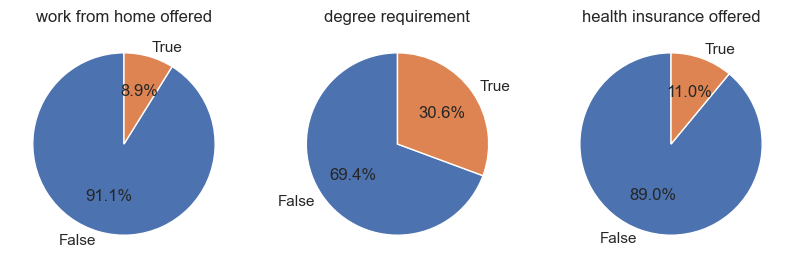

In [98]:
dict_column = {
    'job_work_from_home':'work from home offered',
    'job_no_degree_mention': 'degree requirement',
    'job_health_insurance': 'health insurance offered'
}

fig, ax = plt.subplots(1,3)
fig.set_size_inches(10,20)
for i,(column,title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), labels = ['False','True'],autopct ='%1.1f%%' ,startangle = 90 )
    ax[i].set_title(title)

plt.show()

# Explratory Data Analysis for Data Scientist in India

In [99]:
df_DS_IND = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'India')]

df_DS_IND

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
19,Data Scientist,Data Scientist,"Pune, Maharashtra, India",via Indeed,Full-time,False,India,2023-04-26 13:20:12,False,False,India,None,NaN,NaN,Bitwise Solutions,"[r, sql, python, scala, java, c++, hadoop, tab...","{'analyst_tools': ['tableau'], 'libraries': ['..."
29,Data Scientist,Data Scientist,"Pune, Maharashtra, India",via Exusia,Full-time,False,India,2023-03-26 13:16:20,False,False,India,None,NaN,NaN,Exusia,None,None
239,Data Scientist,Power BI Data Analytics & Data Scientist,"Maharashtra, India",via Shine,Full-time,False,India,2023-11-11 13:10:08,False,False,India,None,NaN,NaN,Emerson,[power bi],{'analyst_tools': ['power bi']}
323,Data Scientist,Forecasting Analyst,Anywhere,via LinkedIn,Full-time,True,India,2023-09-28 13:48:45,False,False,India,None,NaN,NaN,Straive,[excel],{'analyst_tools': ['excel']}
389,Data Scientist,Data Scientist,"New Delhi, Delhi, India",via LinkedIn,Contractor,False,India,2023-09-12 13:16:27,False,False,India,None,NaN,NaN,Digital India Corporation,"[sql, sas, sas, excel, powerpoint, tableau]","{'analyst_tools': ['sas', 'excel', 'powerpoint..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785591,Data Scientist,Data Scientist T8,"Bengaluru, Karnataka, India",via BeBee India,Full-time,False,India,2023-01-01 06:29:03,False,False,India,None,NaN,NaN,Mercedes-Benz Research and Development India P...,"[java, python, aws, azure, kubernetes, docker,...","{'async': ['jira', 'confluence'], 'cloud': ['a..."
785645,Data Scientist,Data Science Intern,Anywhere,via LinkedIn,Internship,True,India,2023-01-20 06:51:23,False,False,India,None,NaN,NaN,TwiLearn EduTech Pvt. Ltd.,"[python, tableau]","{'analyst_tools': ['tableau'], 'programming': ..."
785654,Data Scientist,Data Science Intern,Anywhere,via LinkedIn,None,True,India,2023-01-31 06:11:46,False,False,India,None,NaN,NaN,Corizo,[zoom],{'sync': ['zoom']}
785674,Data Scientist,Data Scientist,"Kolkata, West Bengal, India",via LinkedIn,Full-time,False,India,2023-01-12 06:12:32,False,False,India,None,NaN,NaN,One Billion Ideas Pvt. LTD.,"[r, python, sql, scala, java, c++, matplotlib,...","{'analyst_tools': ['tableau'], 'libraries': ['..."


# Location to explore

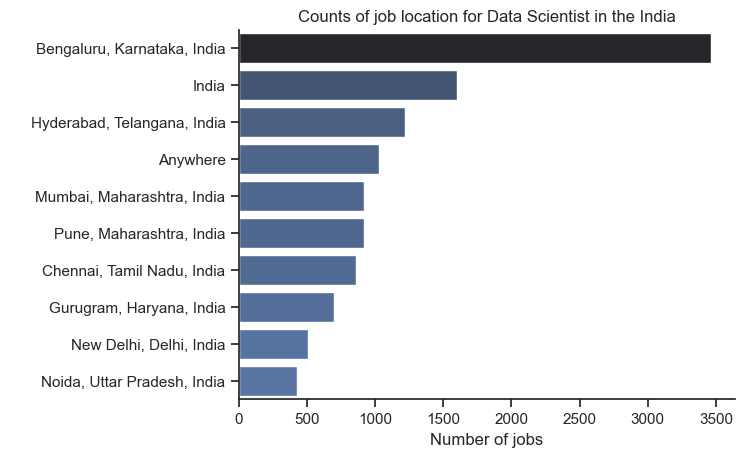

In [100]:
df_plot = df_DS_IND['job_location'].value_counts().to_frame().head(10)


sns.set_theme(style='ticks')
sns.barplot(data = df_plot, x='count',y='job_location',hue= 'count', palette ='dark:b_r',legend=False)
sns.despine()
plt.title('Counts of job location for Data Scientist in the India')
plt.ylabel(" ")
plt.xlabel('Number of jobs')
plt.show()

# job oppertunities

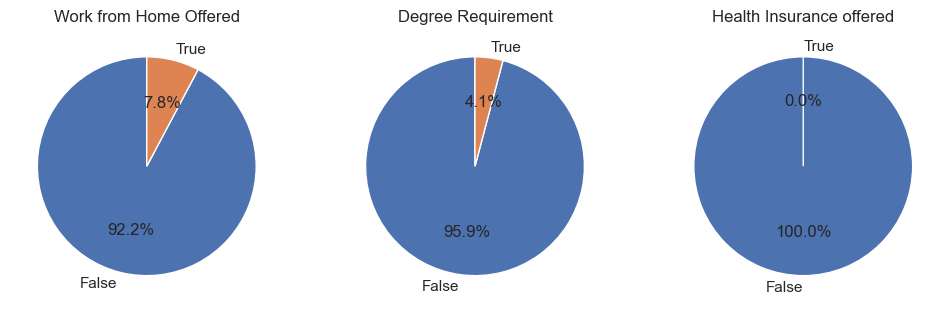

In [101]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention':'Degree Requirement',
    'job_health_insurance':'Health Insurance offered'
}

fig, ax= plt.subplots(1,3)
fig.set_size_inches((12,5))

for i,(column,title) in enumerate(dict_column.items()):
    counts = df_DS_IND[column].value_counts().reindex([False, True], fill_value=0)
    ax[i].pie(counts, labels = ['False','True'] ,autopct = '%1.1f%%', startangle=90)
    ax[i].set_title(title)

# Companies to explore

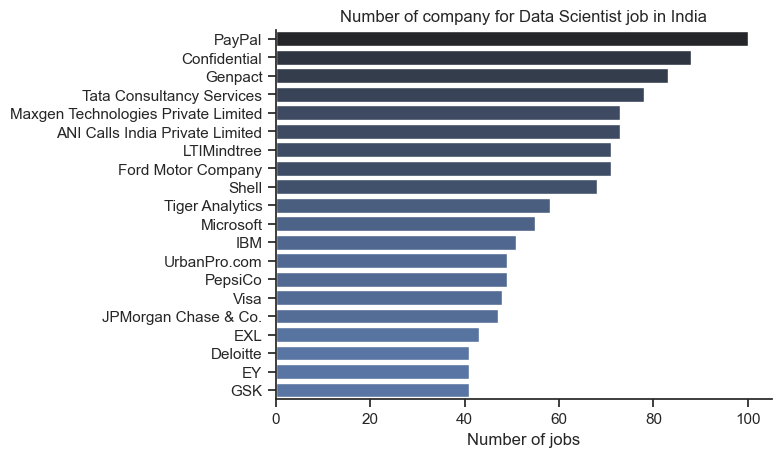

In [107]:
df_plot = df_DS_IND['company_name'].value_counts().to_frame().head(20)

sns.set_theme(style='ticks')
sns.barplot(data = df_plot,x='count' ,y= 'company_name', hue = 'count', palette= 'dark:b_r',legend=False)
sns.despine()
plt.title('Number of company for Data Scientist job in India')
plt.ylabel('')
plt.xlabel('Number of jobs')
plt.show()